## 6. Regression

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=iOJbOfPHXLg&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience06.png)](https://www.youtube.com/watch?v=iOJbOfPHXLg&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Regression ist der Prozess, Modellparameter so anzupassen, dass eine Vorhersage ``y`` zu den Messwerten ``z`` passt. Es gibt unabhängige Variablen ``x`` als Eingaben für das Modell, um die Vorhersagen ``y`` zu erzeugen. Im Machine Learning besteht das Ziel darin, durch Anpassen der Modellparameter eine __Verlustfunktion__ zu minimieren. Eine häufige Verlustfunktion ist die Summe der quadrierten Fehler zwischen dem vorhergesagten ``y`` und dem gemessenen ``z``.

    x = Unabhängige Variable, Input, Feature
    y = Abhängige Variable, Output, Label
    z = Ausgangsmessung

![Temperatur](https://apmonitor.com/che263/uploads/Begin_Python/temperature.png)

Das Ziel ist, eine Verlustfunktion zu minimieren, etwa die Summe der quadrierten Fehler zwischen gemessenen und vorhergesagten Werten:

$Loss = \sum_{i=1}^{n}\left(y_i-z_i\right)^2$

wobei ``n`` die Anzahl der Beobachtungen ist. Regression benötigt gelabelte Daten (als Kontrollfunktion und Ziel zum anpassen der Parameter) für das Training. Klassifikation kann dagegen entweder überwacht sein (mit ``z``-Messwerten, Labels) oder unüberwacht (ohne Labels, ``z``-Messwerte). Führe den folgenden Code aus, um 30 Beispieldatenpunkte mit Eingabe ``x`` und gemessenem Output ``z`` zu laden.

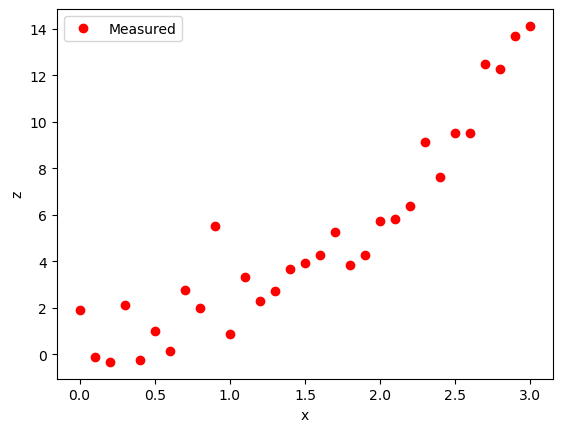

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
n = 31
x = np.linspace(0,3,n)
z = np.array([1.89,-0.12,-0.32,2.11,-0.25,1.01,0.17,2.75,2.01,5.5,\
     0.87,3.31,2.29,2.73,3.67,3.92,4.29,5.27,3.85,4.26,\
     5.75,5.82,6.36,9.13,7.61,9.52,9.53,12.49,12.29,13.7,14.12])
data = pd.DataFrame(np.vstack((x,z)).T,columns=['x','z'])
plt.plot(x,z,'ro',label='Measured')
plt.xlabel('x'); plt.ylabel('z'); plt.legend()
plt.show()

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Lineare Regression

Es gibt viele Modellformen, z. B. lineare, polynomiale und nichtlineare. Ein __vertrautes__ lineares Modell ist eine Gerade mit Steigung ``a`` und Achsenabschnitt ``b``.

    y = a x + b
    

Eine einfache Methode für lineare Regression ist mit ``numpy``, um ``p = np.polyfit(x, y, 1)`` zu fitten und das Modell mit ``np.polyval(p, x)`` auszuwerten. Führe den folgenden Code aus, um die Steigung und den Achsenabschnitt zu bestimmen, die die Summe der quadrierten Fehler zwischen dem vorhergesagten ``y`` und dem gemessenen Output ``z`` minimieren.

Slope, Intercept:[ 4.22197581 -1.31586694]


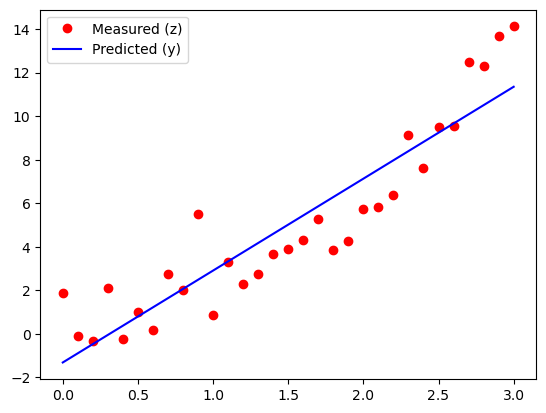

In [7]:
p1 = np.polyfit(x,z,1)

print('Slope, Intercept:' + str(p1))

plt.plot(x,z,'ro',label='Measured (z)')
plt.plot(x,np.polyval(p1,x),'b-',label='Predicted (y)')
plt.legend(); plt.show()

Der $R^2$-Wert kann für jedes Regressionsmodell (nicht nur lineare) aus gemessenen (True) und modellierten (predict) Werten berechnet werden.

```python
from sklearn.metrics import r2_score
meas  = [3.0, 2.0, 1.9, 7.1]
model = [2.5, 1.8, 2.0, 8.0]
r2_score(meas, model)
```

Ein weiteres nützliches Paket ist ``statsmodels``, das eine Standard-OLS-Analyse (Ordinary Least Squares) mit übersichtlicher Ergebniszusammenfassung durchführt. Viele weitere stistische Testverfahren sind dort implementiert und wir werden diese Bibliothek öfter benutzen insbesondere bei Zeitreihendaten.

Der Input ``x`` wird um eine Spalte ``np.ones(n)`` ergänzt, sodass auch der Achsenabschnitt geschätzt wird:

```python
xc = np.vstack((x,np.ones(n))).T
```

Dies lässt sich bequemer mit ``xc = sm.add_constant(x)`` erreichen. 

In [13]:
import statsmodels.api as sm
xc = sm.add_constant(x)
model = sm.OLS(z,xc).fit()
predictions = model.predict(xc)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     150.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           5.41e-13
Time:                        14:08:17   Log-Likelihood:                -59.683
No. Observations:                  31   AIC:                             123.4
Df Residuals:                      29   BIC:                             126.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3159      0.602     -2.187      0.037      -2.546      -0.085
x1             4.2220      0.344     12.256      0.000       3.517       4.926
==============================================================================
Omnibus:                        3.249   Durbin-Watson:                   1.081
Prob(Omnibus):                  0.197   Jarque-Bera (JB):                2.351
Skew:                           0.511   Prob(JB):                        0.309
Kurtosis:                       2.118   Cond. No.                         4.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Übung zur Linearen Regression

Erstelle ein lineares Modell mit den Daten:

```python
xr = [0.0,1.0,2.0,3.5,5.0]
yr = [0.7,0.55,0.34,0.3,0.2]
```

Berechne den $R^2$-Wert und zeige die Daten sowie den linearen Fit in einem Diagramm.

R²-Wert: 0.8972384776880264


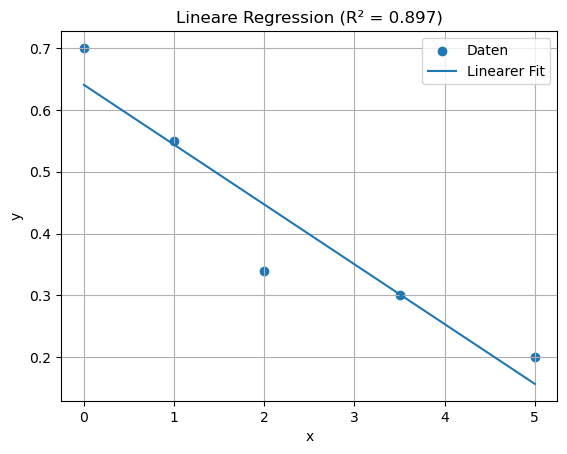

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Gegebene Daten
xr = np.array([0.0, 1.0, 2.0, 3.5, 5.0]).reshape(-1, 1)
yr = np.array([0.7, 0.55, 0.34, 0.3, 0.2])

# Lineares Regressionsmodell erstellen und trainieren
model = LinearRegression()
model.fit(xr, yr)

# Vorhersage mit dem Modell
yr_pred = model.predict(xr)

# R²-Wert berechnen
r2 = r2_score(yr, yr_pred)
print("R²-Wert:", r2)

# Diagramm erstellen
plt.figure()

# Originaldaten
plt.scatter(xr, yr, label="Daten")

# Linearer Fit
plt.plot(xr, yr_pred, label="Linearer Fit")

# Achsen beschriften
plt.xlabel("x")
plt.ylabel("y")

# Titel hinzufügen
plt.title("Lineare Regression (R² = {:.3f})".format(r2))

# Legende anzeigen
plt.legend()

# Gitter anzeigen
plt.grid(True)

# Diagramm anzeigen
plt.show()


![debug](https://apmonitor.com/che263/uploads/Begin_Python/debug.png)

### Polynomiale Regression

Ein polynomiales Modell kann auch quadratisch sein:

    y = a x^2 + b x + c
    
Ein quadratisches Modell ist eigentlich nur ein lineares Modell mit zwei Eingaben ``x`` und ``z = x^2``.

    y = a z + b x + c
    
Dies wird auch multiple lineare Regression genannt, wenn es mehr als eine Eingabe gibt, ``y = f(x, z)``, wobei ``f`` eine Funktion der Eingaben ``x`` und ``z`` ist.


[ 1.71448706 -0.92148536  1.1701393 ]


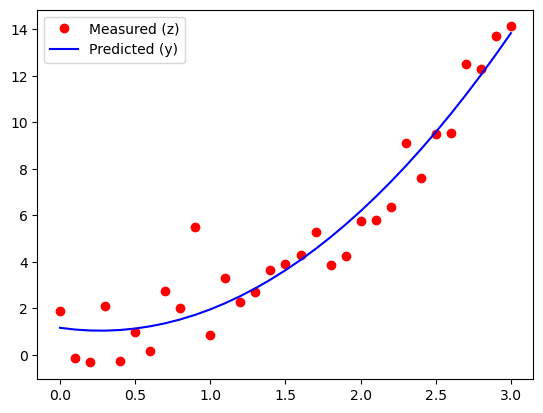

In [19]:
p2 = np.polyfit(x,z,2)
print(p2)
plt.plot(x,z,'ro',label='Measured (z)')
plt.plot(x,np.polyval(p2,x),'b-',label='Predicted (y)')
plt.legend(); plt.show()

Mit ``statsmodels`` erhältst du für den quadratischen Fit weitergehende Informationen zu den geschätzten Koeffizienten.

In [22]:
import statsmodels.api as sm
xc = np.vstack((x**2,x,np.ones(n))).T
model = sm.OLS(z,xc).fit()
predictions = model.predict(xc)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     176.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.38e-16
Time:                        14:09:37   Log-Likelihood:                -47.478
No. Observations:                  31   AIC:                             101.0
Df Residuals:                      28   BIC:                             105.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.7145      0.296      5.791      0.000       1.108       2.321
x2            -0.9215      0.919     -1.003      0.325      -2.804       0.961
const          1.1701      0.596      1.964      0.059      -0.050       2.390
==============================================================================
Omnibus:                       10.651   Durbin-Watson:                   2.279
Prob(Omnibus):                  0.005   Jarque-Bera (JB):                9.985
Skew:                           1.042   Prob(JB):                      0.00679
Kurtosis:                       4.841   Cond. No.                         23.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Übung zur polynomialen Regression

Erstelle ein polynomiales Modell mit den Daten:

```python
xr = [0.0,1.0,2.0,3.5,5.0]
yr = [1.7,1.45,1.05,0.4,0.2]
```

Zeige das polynomiale Modell in einem Diagramm.

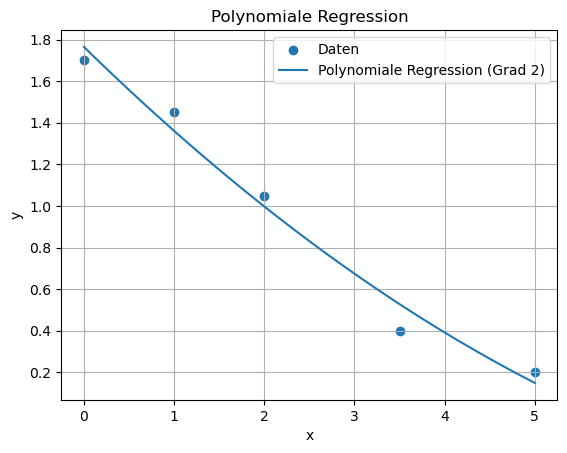

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Gegebene Daten
xr = np.array([0.0, 1.0, 2.0, 3.5, 5.0]).reshape(-1, 1)
yr = np.array([1.7, 1.45, 1.05, 0.4, 0.2])

# Polynomiale Features (Grad 2)
poly = PolynomialFeatures(degree=2)
xr_poly = poly.fit_transform(xr)

# Lineares Modell auf den polynomialen Features
model = LinearRegression()
model.fit(xr_poly, yr)

# Feinere x-Werte für eine glatte Kurve
xr_plot = np.linspace(xr.min(), xr.max(), 100).reshape(-1, 1)
xr_plot_poly = poly.transform(xr_plot)

# Vorhersage mit dem Modell
yr_pred = model.predict(xr_plot_poly)

# Diagramm erstellen
plt.figure()

# Originaldaten
plt.scatter(xr, yr, label="Daten")

# Polynomiale Regression
plt.plot(xr_plot, yr_pred, label="Polynomiale Regression (Grad 2)")

# Achsen beschriften
plt.xlabel("x")
plt.ylabel("y")

# Titel hinzufügen
plt.title("Polynomiale Regression")

# Legende anzeigen
plt.legend()

# Gitter anzeigen
plt.grid(True)

# Diagramm anzeigen
plt.show()


![list](https://apmonitor.com/che263/uploads/Begin_Python/list.png)

### Nichtlineare Regression

Nichtlineare Regression erfordert ein anderes Werkzeug wie ``curve_fit``, das eine Funktion ``f`` benötigt, die eine Vorhersage zurückgibt. Außerdem werden die Daten ``x`` und ``z`` benötigt. Die unbekannten Parameter ``a`` und ``b`` werden so angepasst, dass der vorhergesagte Output mit dem gemessenen Output ``z`` übereinstimmt.

p = [0.88676183 0.93776713]


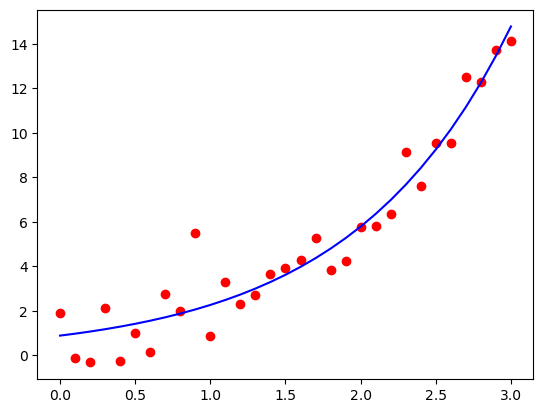

In [26]:
from scipy.optimize import curve_fit
def f(x,a,b):
    return a * np.exp(b*x)
p, pcov = curve_fit(f,x,z)
print('p = '+str(p))
plt.plot(x,z,'ro')
plt.plot(x,f(x,*p),'b-')
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Übung zur nichtlinearen Regression

Erstelle ein nichtlineares Modell mit den Daten:

$y = a \ln\left( b \, x \right)$

```python
xr = [0.1,1.0,2.0,3.5,5.0]
yr = [0.2,0.4,1.05,1.45,1.7]
```

Zeige das nichtlineare Modell in einem Diagramm.

Gefundene Parameter:
a = 0.375687645992521
b = 10.021789396980612


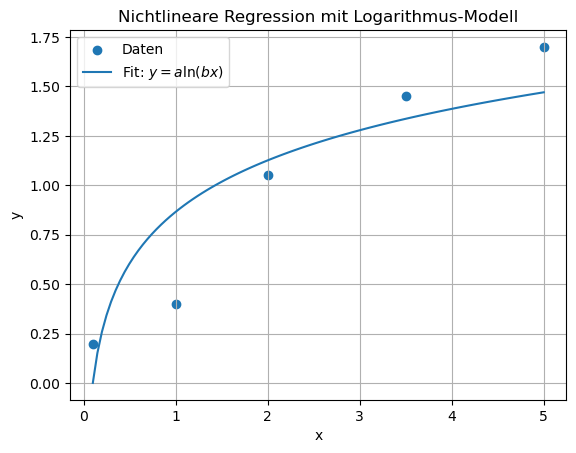

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gegebene Daten
xr = np.array([0.1, 1.0, 2.0, 3.5, 5.0])
yr = np.array([0.2, 0.4, 1.05, 1.45, 1.7])

# Nichtlineares Modell definieren: y = a * ln(b * x)
def log_model(x, a, b):
    return a * np.log(b * x)

# Startwerte für die Parameter (wichtig für nichtlineare Fits)
startwerte = [1.0, 1.0]

# Parameter a und b schätzen
params, _ = curve_fit(log_model, xr, yr, p0=startwerte)
a, b = params

print("Gefundene Parameter:")
print("a =", a)
print("b =", b)

# Feinere x-Werte für eine glatte Kurve
xr_plot = np.linspace(xr.min(), xr.max(), 100)

# Modellvorhersage
yr_pred = log_model(xr_plot, a, b)

# Diagramm erstellen
plt.figure()

# Originaldaten
plt.scatter(xr, yr, label="Daten")

# Nichtlinearer Fit
plt.plot(xr_plot, yr_pred, label=r"Fit: $y = a \ln(bx)$")

# Achsen beschriften
plt.xlabel("x")
plt.ylabel("y")

# Titel hinzufügen
plt.title("Nichtlineare Regression mit Logarithmus-Modell")

# Legende anzeigen
plt.legend()

# Gitter anzeigen
plt.grid(True)

# Diagramm anzeigen
plt.show()


![exercise](https://apmonitor.com/che263/uploads/Begin_Python/exercise.png)

### Maschinelles Lernen

Maschinelles Lernen umfasst Computeralgorithmen und statistische Modelle, die auf Mustern und Inferenz beruhen. Sie führen eine bestimmte Aufgabe ohne explizite Anweisungen aus. Durch maschinelles Lernen gewonnene Regressionsmodelle können so einfach wie lineare Regression oder so komplex wie Deep Learning sein. Dieses Tutorial zeigt mehrere Regressionsmethoden mit ``scikit-learn``.

#### Daten erzeugen

Um das Diagramm interaktiv zu machen, füge den Befehl hinzu: 

```python
%matplotlib notebook
```

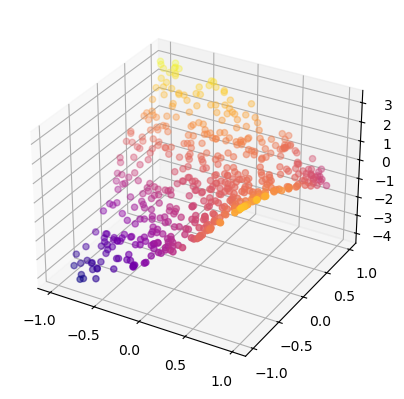

In [36]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

import math
def f(x,y):
    return 2*math.cos(x)*y + x*math.cos(y) - 3*x*y

n = 500
x = (np.random.rand(n)-0.5)*2.0
y = (np.random.rand(n)-0.5)*2.0
z = np.empty_like(x)
for i in range(n):
    z[i] = f(x[i],y[i])
data = pd.DataFrame(np.vstack((x,y,z)).T,columns=['x','y','z'])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z,c=z,cmap='plasma')
plt.show()

#### Daten skalieren

Die Daten können mit einem StandardScaler skaliert oder unskaliert belassen werden, da die Werte von ``x``, ``y`` und ``z`` bereits in akzeptablen Bereichen liegen. Wenn eine Skalierung gewünscht ist, lässt sie sich mit wenigen zusätzlichen Codezeilen und Anpassungen der Diagramme durchführen.

```python
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
ds = s.fit_transform(data)
ds = pd.DataFrame(ds,columns=data.columns)
```

Die Daten werden mit ``train_test_split`` in Trainings- und Testmengen aufgeteilt.

In [39]:
# keine Datenskalierung
ds = data

# Aufteilen der Daten in Trainings- und Testmengen
from sklearn.model_selection import train_test_split
train,test = train_test_split(ds, test_size=0.2, shuffle=True)

#### Funktion zum Plotten

Führe diesen Code aus, damit jedes der Regressor-Modelle trainiert und in einem 3D-Streu- und Flächendiagramm angezeigt wird.


In [42]:
def fit(method):
    # create points for plotting surface
    xp = np.arange(-1, 1, 0.1)
    yp = np.arange(-1, 1, 0.1)
    XP, YP = np.meshgrid(xp, yp)

    model = method.fit(train[['x','y']],train['z'])
    zp = method.predict(np.vstack((XP.flatten(),YP.flatten())).T)
    ZP = zp.reshape(np.size(XP,0),np.size(XP,1))

    r2 = method.score(test[['x','y']],test['z'])
    print('R^2: ' + str(r2))

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(ds['x'],ds['y'],ds['z'],c=z,cmap='plasma',label='data')
    ax.plot_surface(XP, YP, ZP, cmap='coolwarm',alpha=0.7,
                    linewidth=0, antialiased=False)
    plt.show()
    return

#### Lineare Regression mit `sklearn`

Der einfachste Regressor ist ein lineares Modell. Wie zu erwarten, liefert dieses Modell bei den nichtlinearen Daten keine besonders gute Leistung, erfasst jedoch die Steigung der Daten.

C:\Users\eichhorn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R^2: 0.4898044295794971


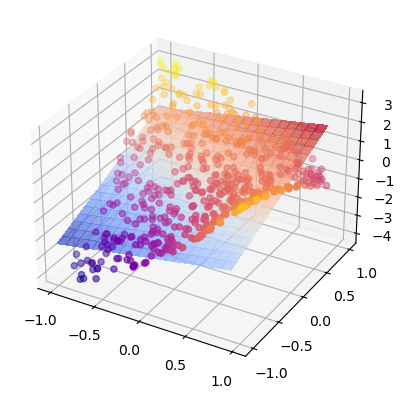

In [45]:
from sklearn import linear_model
lm = linear_model.LinearRegression()
fit(lm)

#### K-nächste Nachbarn

C:\Users\eichhorn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


R^2: 0.9924282450769354


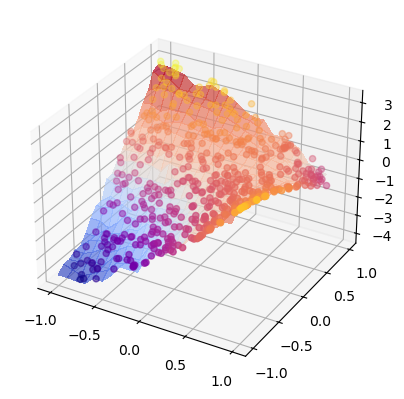

In [48]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=2)
fit(knn)

#### Support-Vektor-Regressor

C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


R^2: 0.9981127743778351


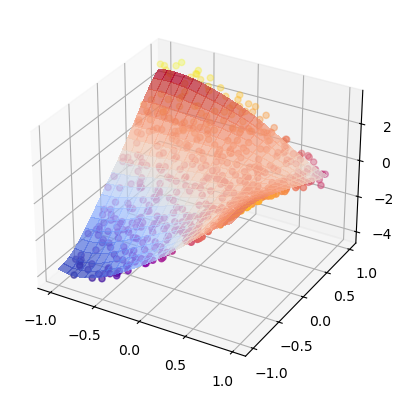

In [17]:
from sklearn import svm
s = svm.SVR(gamma='scale')
fit(s)

#### Mehrschichtiges Perzeptron (Neuronales Netz)

C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


R^2: 0.9987125884474459


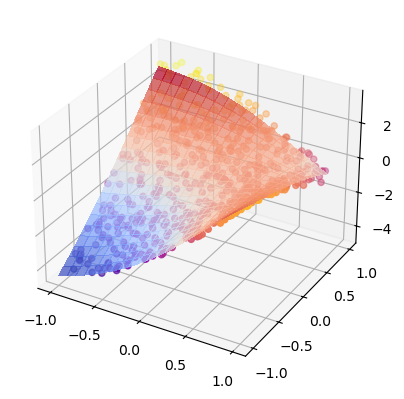

In [18]:
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(hidden_layer_sizes=(3), 
                  activation='tanh', solver='lbfgs')
fit(nn)

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Regressor-Übung

Finde einen weiteren [Regressor in scikit-learn](https://scikit-learn.org/stable/supervised_learning.html), z. B. *Decision Tree Regressor* oder *Passive Agressive Regressor*. Trainiere und teste den Regressor in diesem Notebook mit der Funktion ``fit()``, indem du das Regressor-Objekt übergibst, zum Beispiel:

*Decision Tree Regressor*

```python
from sklearn import tree
dt = tree.DecisionTreeRegressor()
fit(dt)
```

*Passive Aggressive Regressor*

```python
from sklearn.linear_model import PassiveAggressiveRegressor
par = PassiveAggressiveRegressor(max_iter=2000,tol=1e-3)
fit(par)
```

Ändere die Optionen des Regressors, wenn du den $R^2$-Wert verbessern kannst, etwa beim ``PassiveAggressiveRegressor`` mit ``max_iter=2000``.


C:\Users\eichhorn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


R^2: 0.957358462486387


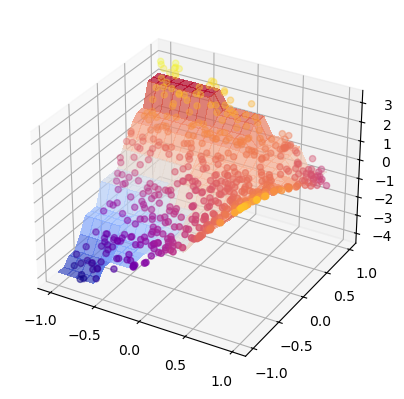

In [50]:
# Decision Tree Regressor
from sklearn import tree

# Regressor erstellen (Optionen kannst du verändern)
dt = tree.DecisionTreeRegressor(
    random_state=42,
    max_depth=5,          # z.B. anpassen: None, 3, 5, 10 ...
    min_samples_leaf=5    # z.B. anpassen: 1, 2, 5, 10 ...
)

# Trainieren & testen (Notebook-Funktion)
fit(dt)


![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

### Deep Learning

Deep Learning ist Regression mit einem neuronalen Netz mit mehreren Schichten. Für Regression mit Deep Learning gibt es spezialisierte Pakete wie [Tensorflow für großskalige Daten](https://www.tensorflow.org) oder [Gekko für konfigurierbare Modellstrukturen](https://gekko.readthedocs.io/en/latest/). Unten steht eines der Beispiele aus einem Deep-Learning-Tutorial mit Gekko. Dasselbe Beispiel mit Keras (Tensorflow) ist im Link ebenfalls gezeigt.

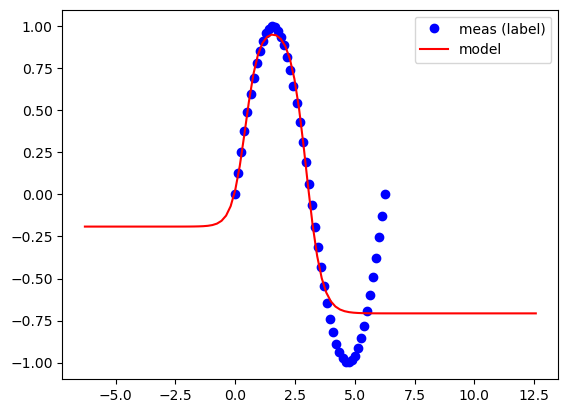

In [53]:
from gekko import brain
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0,2*np.pi)
y = np.sin(x)

b = brain.Brain(remote=False)
b.input_layer(1)
b.layer(linear=2)
b.layer(tanh=2)
b.layer(linear=2)
b.output_layer(1)
b.learn(x,y,disp=False)      

xp = np.linspace(-2*np.pi,4*np.pi,100)
yp = b.think(xp)  

plt.figure()
plt.plot(x,y,'bo',label='meas (label)')
plt.plot(xp,yp[0],'r-',label='model')
plt.legend(); plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab-Übung

### Temperaturen aufzeichnen

![connections](https://apmonitor.com/che263/uploads/Begin_Python/connections.png)

Stelle Heizer 1 auf 80 % mit ``lab.Q1(80)`` und Heizer 2 auf 60 % mit ``lab.Q2(60)``. Zeichne die Temperaturen (``lab.T1`` und ``lab.T2``) 30 Sekunden lang alle 0,5 Sekunden auf (verwende ``time.sleep(0.5)``). Speichere die Werte für Zeit, Temperatur 1 und Temperatur 2 in ``numpy``-Arrays. Verwende __time.time()__, um die aktuelle Zeit in Sekunden zu erhalten.


In [56]:
import time
import numpy as np
from tclab import TCLab

# Messparameter
dt = 0.5          # Abtastzeit (Sekunden)
dauer = 30.0      # Gesamtdauer (Sekunden)
n = int(dauer / dt)

# Arrays für Zeit und Temperaturen
zeit = np.zeros(n)
T1 = np.zeros(n)
T2 = np.zeros(n)

with TCLab() as lab:

    # Heizer einstellen
    lab.Q1(80)
    lab.Q2(60)

    # Startzeit
    t_start = time.time()
    t_next = t_start

    for i in range(n):
        # Warten bis zum exakten nächsten Messzeitpunkt
        while time.time() < t_next:
            pass

        # Zeit relativ zum Start speichern
        zeit[i] = time.time() - t_start
        T1[i] = lab.T1
        T2[i] = lab.T2

        print(f"t = {zeit[i]:.2f} s | T1 = {T1[i]:.2f} °C | T2 = {T2[i]:.2f} °C")

        # Nächsten Messzeitpunkt festlegen
        t_next += dt

    # Heizer ausschalten
    lab.Q1(0)
    lab.Q2(0)

print("Messung abgeschlossen.")


TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
t = 0.00 s | T1 = 21.96 °C | T2 = 21.51 °C
t = 0.50 s | T1 = 21.90 °C | T2 = 21.22 °C
t = 1.00 s | T1 = 21.86 °C | T2 = 21.22 °C
t = 1.51 s | T1 = 21.86 °C | T2 = 21.35 °C
t = 2.00 s | T1 = 21.86 °C | T2 = 21.41 °C
t = 2.50 s | T1 = 21.90 °C | T2 = 21.22 °C
t = 3.01 s | T1 = 21.86 °C | T2 = 21.61 °C
t = 3.51 s | T1 = 21.96 °C | T2 = 21.48 °C
t = 4.01 s | T1 = 21.96 °C | T2 = 21.35 °C
t = 4.51 s | T1 = 21.93 °C | T2 = 21.61 °C
t = 5.01 s | T1 = 21.93 °C | T2 = 21.57 °C
t = 5.51 s | T1 = 21.96 °C | T2 = 21.25 °C
t = 6.00 s | T1 = 21.96 °C | T2 = 21.54 °C
t = 6.51 s | T1 = 22.03 °C | T2 = 21.61 °C
t = 7.01 s | T1 = 21.96 °C | T2 = 21.25 °C
t = 7.51 s | T1 = 22.06 °C | T2 = 21.61 °C
t = 8.01 s | T1 = 22.09 °C | T2 = 21.41 °C
t = 8.51 s | T1 = 22.09 °C | T2 = 21.41 °C
t = 9.01 s | T1 = 22.16 °C | T2 = 21.61 °C
t = 9.50 s | T1 = 22.16 °C | T2 = 21.61 °C
t = 10.01 s | T1 = 

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Lineare Regression

Erstelle ein lineares Modell für ``T2`` mittels Regression. Gib den $R^2$-Wert an. Füge die Regressionsgerade als schwarze Linie zu einem Diagramm hinzu, in dem die gemessenen ``T2`` als blaue Kreise dargestellt sind. Ergänze passende Beschriftungen für das Diagramm.


R²-Wert: 0.7150555107269871


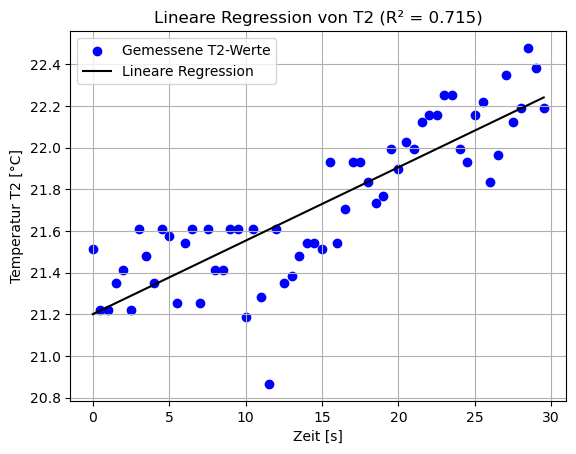

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Zeit als Feature (2D-Array für scikit-learn)
X = zeit.reshape(-1, 1)
y = T2

# Lineares Regressionsmodell erstellen und trainieren
model = LinearRegression()
model.fit(X, y)

# Vorhersage berechnen
y_pred = model.predict(X)

# R²-Wert berechnen
r2 = r2_score(y, y_pred)
print("R²-Wert:", r2)

# Diagramm erstellen
plt.figure()

# Gemessene T2-Werte (blaue Kreise)
plt.scatter(zeit, T2, color="blue", label="Gemessene T2-Werte")

# Regressionsgerade (schwarze Linie)
plt.plot(zeit, y_pred, color="black", label="Lineare Regression")

# Achsen beschriften
plt.xlabel("Zeit [s]")
plt.ylabel("Temperatur T2 [°C]")

# Titel hinzufügen
plt.title(f"Lineare Regression von T2 (R² = {r2:.3f})")

# Legende anzeigen
plt.legend()

# Gitter anzeigen
plt.grid(True)

# Diagramm anzeigen
plt.show()


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Nichtlineare Regression

Erstelle eine nichtlineare Regression für ``T1``. Fitte die $T_1$-Daten mit:

1. einem nichtlinearen Modell der Form $T_1 = a + b \exp{(c \, t)}$ wobei `a`, `b`, und `c` anpassbare Parameter sind.
2. einem nichtlinearen Modell unter Verwendung eines Regressors in `scikit-learn`, `keras (tensorflow)`, oder `gekko`

Gib für jedes Modell den $R^2$-Wert an.

Modell 1: Exponentiell (curve_fit)
a = 21.468280419544232
b = 0.3396339034349001
c = 0.07330143721193232
R² = 0.9941143420465712

Modell 2: Polynomregression (scikit-learn)
Grad = 3
R² = 0.9965733297194733


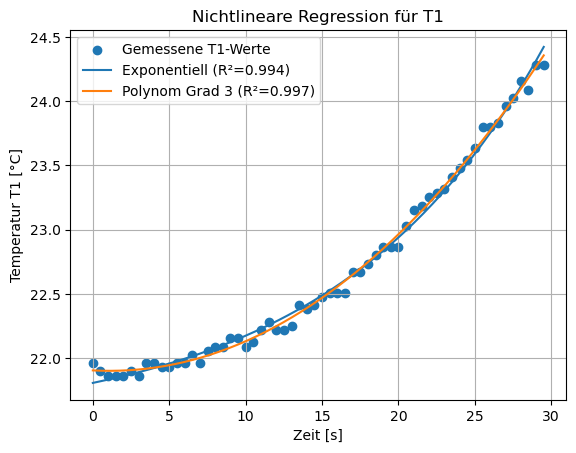

In [61]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# Daten vorbereiten

t = np.array(zeit, dtype=float)
y = np.array(T1, dtype=float)

# Für scikit-learn als 2D-Array
X = t.reshape(-1, 1)


# (1) Exponentielles Modell: T1 = a + b * exp(c * t)

def exp_model(t, a, b, c):
    return a + b * np.exp(c * t)

# Startwerte (hilft der Konvergenz)
# a ~ Startwert, b ~ Differenz, c ~ kleine Zahl (Erwärmung meist langsam)
p0 = [y.min(), (y.max() - y.min()), 0.01]

# Parameter fitten
params, _ = curve_fit(exp_model, t, y, p0=p0, maxfev=20000)
a, b, c = params

# Vorhersage auf Messpunkten für R²
y_pred_exp = exp_model(t, a, b, c)
r2_exp = r2_score(y, y_pred_exp)

print("Modell 1: Exponentiell (curve_fit)")
print("a =", a)
print("b =", b)
print("c =", c)
print("R² =", r2_exp)


# (2) Nichtlineares Modell mit scikit-learn Regressor
#     (Polynomial Regression als nichtlinearer Regressor)

grad = 3  # Grad kannst du anpassen (2, 3, 4 ...)
poly = PolynomialFeatures(degree=grad, include_bias=False)

X_poly = poly.fit_transform(X)

reg = LinearRegression()
reg.fit(X_poly, y)

y_pred_poly = reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)

print("\nModell 2: Polynomregression (scikit-learn)")
print("Grad =", grad)
print("R² =", r2_poly)


# Diagramm: Daten + beide Fits

t_plot = np.linspace(t.min(), t.max(), 200)
X_plot = t_plot.reshape(-1, 1)

# Exponentieller Fit für glatte Kurve
y_plot_exp = exp_model(t_plot, a, b, c)

# Polynom-Fit für glatte Kurve
X_plot_poly = poly.transform(X_plot)
y_plot_poly = reg.predict(X_plot_poly)

plt.figure()

# Messdaten
plt.scatter(t, y, label="Gemessene T1-Werte")

# Exponentieller Fit
plt.plot(t_plot, y_plot_exp, label=f"Exponentiell (R²={r2_exp:.3f})")

# Polynom-Fit (scikit-learn)
plt.plot(t_plot, y_plot_poly, label=f"Polynom Grad {grad} (R²={r2_poly:.3f})")

plt.xlabel("Zeit [s]")
plt.ylabel("Temperatur T1 [°C]")
plt.title("Nichtlineare Regression für T1")
plt.grid(True)
plt.legend()
plt.show()
